In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# 각 열 결측치 개수 확인
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
# 중복 행 개수 확인
df.duplicated().sum()

1081

In [8]:
# 정상 거래(0)와 사기 거래(1) 개수 확인
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
# 거래 금액(Amount) 기초 통계 확인
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

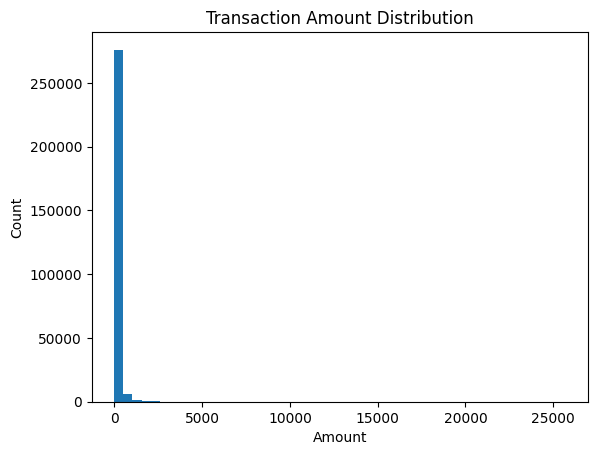

In [10]:
# 거래 금액 분포 확인
plt.hist(df["Amount"], bins=50)
plt.xlabel("Amount")
plt.ylabel("Count")
plt.title("Transaction Amount Distribution")
plt.show()

In [11]:
# 거래 시간(Time) 기초 통계 확인
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

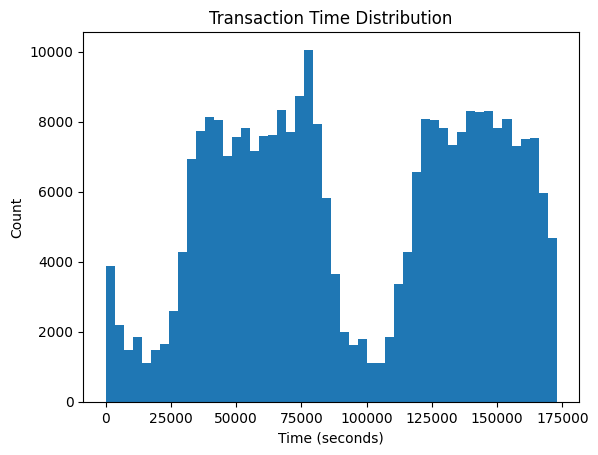

In [12]:
# 거래 시간(Time) 분포 확인
plt.hist(df["Time"], bins=50)
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.title("Transaction Time Distribution")
plt.show()

In [13]:
# 정상 거래와 사기 거래의 시간 분포 비교
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

In [14]:
normal.shape, fraud.shape

((284315, 31), (492, 31))

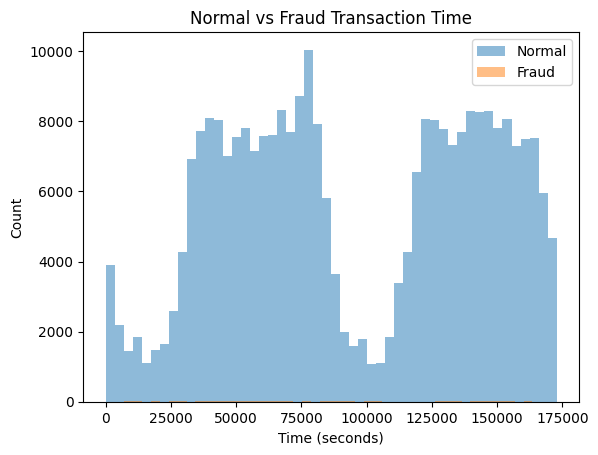

In [15]:
# 정상 거래와 사기 거래의 시간 분포 비교
plt.hist(normal["Time"], bins=50, alpha=0.5, label="Normal")
plt.hist(fraud["Time"], bins=50, alpha=0.5, label="Fraud")

plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.title("Normal vs Fraud Transaction Time")
plt.legend()
plt.show()

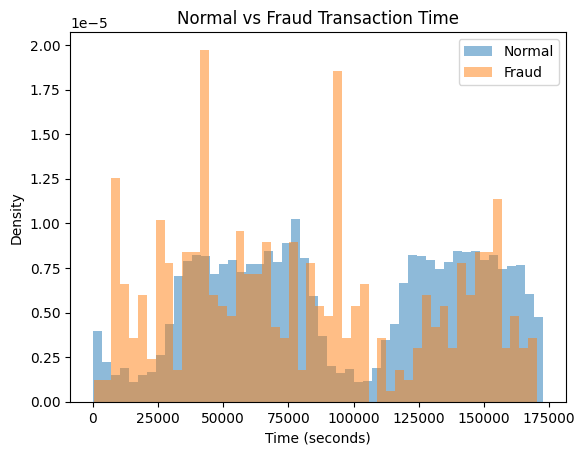

In [16]:
# 정상 거래와 사기 거래의 시간 분포를 비율로 비교
plt.hist(normal["Time"], bins=50, alpha=0.5, label="Normal", density=True)
plt.hist(fraud["Time"], bins=50, alpha=0.5, label="Fraud", density=True)

plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.title("Normal vs Fraud Transaction Time")
plt.legend()
plt.show()
# 정상 거래와 사기 거래의 시간 분포 형태에는 차이가 관찰되지만, 사기 거래 표본이 적으므로 특정 시간대에 사기가 집중된다고 단정하기는 어렵다.

In [17]:
# 정상 거래와 사기 거래의 거래 금액 기초 통계 비교
normal["Amount"].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [18]:
fraud["Amount"].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

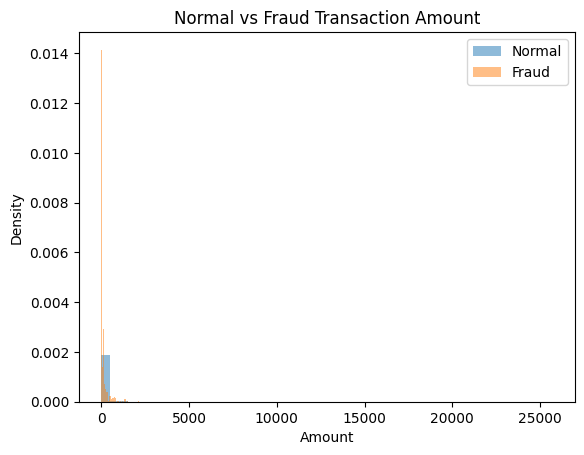

In [19]:
# 정상 거래와 사기 거래의 금액 분포 비교
plt.hist(normal["Amount"], bins=50, alpha=0.5, label="Normal", density=True)
plt.hist(fraud["Amount"], bins=50, alpha=0.5, label="Fraud", density=True)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Normal vs Fraud Transaction Amount")
plt.legend()
plt.show()

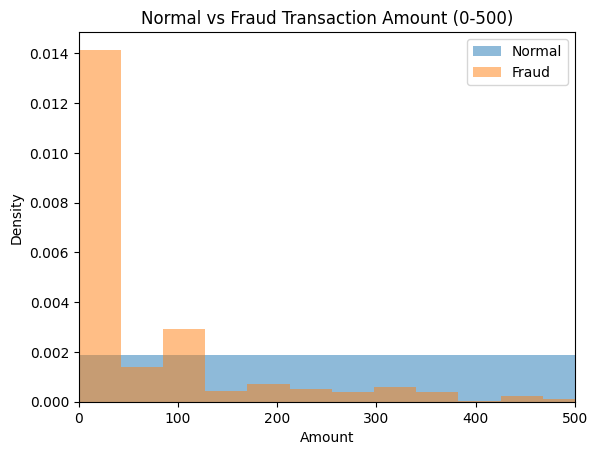

In [20]:
# 거래 금액 0~500 구간 확대 비교
plt.hist(normal["Amount"], bins=50, alpha=0.5, label="Normal", density=True)
plt.hist(fraud["Amount"], bins=50, alpha=0.5, label="Fraud", density=True)

plt.xlim(0, 500)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Normal vs Fraud Transaction Amount (0-500)")
plt.legend()
plt.show()
# 다만 이 방식은 500 초과 데이터도 히스토그램 계산에는 포함하고 화면만 잘라 보는 방식

In [21]:
# 정상/사기 거래별 V1~V28 평균 비교
v_cols = [f"V{i}" for i in range(1, 29)]

df.groupby("Class")[v_cols].mean()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
Class,,,,,,,,,,,,,,,,,,,,,
0,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,...,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131
1,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,...,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667


In [22]:
# 정상과 사기의 평균 차이가 큰 변수 순서대로 확인
v_mean = df.groupby("Class")[v_cols].mean()

mean_diff = (v_mean.loc[1] - v_mean.loc[0]).abs()
mean_diff.sort_values(ascending=False)

V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
V2     3.630049
V5     3.156678
V9     2.585589
V18    2.250195
V6     1.400155
V21    0.714823
V19    0.681837
V8     0.571623
V20    0.372964
V27    0.170870
V13    0.109523
V24    0.105312
V15    0.093090
V28    0.075798
V26    0.051738
V25    0.041521
V23    0.040378
V22    0.014073
dtype: float64

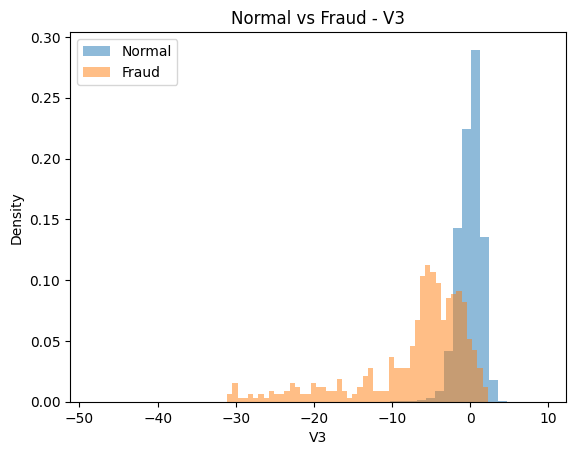

In [23]:
# 정상 거래와 사기 거래의 V3 분포 비교
plt.hist(normal["V3"], bins=50, alpha=0.5, density=True, label="Normal")
plt.hist(fraud["V3"], bins=50, alpha=0.5, density=True, label="Fraud")

# 그래프 제목 및 축 이름 설정
plt.xlabel("V3")
plt.ylabel("Density")
plt.title("Normal vs Fraud - V3")
plt.legend()
plt.show()

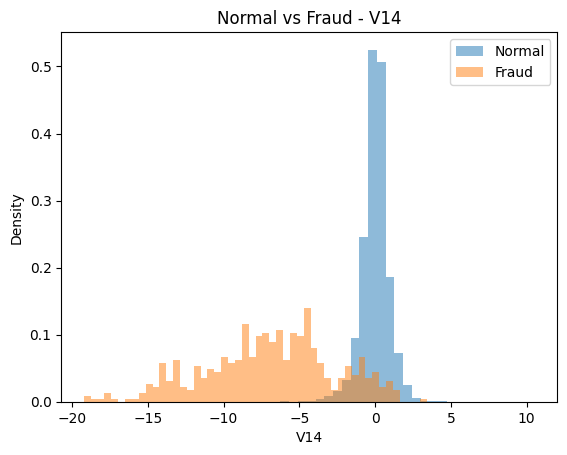

In [24]:
# 정상 거래와 사기 거래의 V14 분포 비교
plt.hist(normal["V14"], bins=50, alpha=0.5, density=True, label="Normal")
plt.hist(fraud["V14"], bins=50, alpha=0.5, density=True, label="Fraud")

# 그래프 제목 및 축 이름 설정
plt.xlabel("V14")
plt.ylabel("Density")
plt.title("Normal vs Fraud - V14")
plt.legend()
plt.show()

In [25]:
# 입력 데이터(X)와 정답 데이터(y) 분리
X = df.drop("Class", axis=1)
y = df["Class"]

# 분리 결과 확인
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [26]:
# Train / Validation / Test 데이터 분할을 위한 함수 불러오기
from sklearn.model_selection import train_test_split

# 1단계: 전체 데이터의 70%를 Train, 나머지 30%를 임시 데이터로 분할
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2단계: 남은 30%를 절반씩 나누어 Validation 15%, Test 15% 생성
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# 최종 분할 크기 확인
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (199364, 30) (199364,)
Validation: (42721, 30) (42721,)
Test: (42722, 30) (42722,)


In [27]:
# Train / Validation / Test의 정상(0), 사기(1) 거래 개수 확인
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
Class
0    199020
1       344
Name: count, dtype: int64

Validation:
Class
0    42647
1       74
Name: count, dtype: int64

Test:
Class
0    42648
1       74
Name: count, dtype: int64


In [28]:
# 각 데이터셋의 사기 거래 비율 확인
print("Train fraud ratio:", y_train.mean())
print("Validation fraud ratio:", y_val.mean())
print("Test fraud ratio:", y_test.mean())

Train fraud ratio: 0.0017254870488152324
Validation fraud ratio: 0.0017321691907960957
Test fraud ratio: 0.0017321286456626562


In [29]:
# 중복 데이터 중 사기 거래(Class=1)가 몇 건 포함되어 있는지 확인
print(df[df.duplicated()]["Class"].value_counts())

Class
0    1062
1      19
Name: count, dtype: int64


In [30]:
# 중복된 거래 데이터를 제거하여 새로운 데이터프레임 생성
df_clean = df.drop_duplicates()

# 중복 제거 전후 데이터 크기 확인
print("Before:", df.shape)
print("After:", df_clean.shape)

# 중복 제거 후 남아 있는 중복 행 개수 확인
print("Duplicates:", df_clean.duplicated().sum())

Before: (284807, 31)
After: (283726, 31)
Duplicates: 0


In [31]:
# 중복 데이터 중 정상(0), 사기(1) 거래 개수 확인
print(df[df.duplicated()]["Class"].value_counts())

Class
0    1062
1      19
Name: count, dtype: int64


In [32]:
# 중복 제거된 데이터에서 입력 데이터(X)와 정답 데이터(y) 분리
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

# 데이터 크기 확인
print("X shape:", X.shape)
print("y shape:", y.shape)

# 중복 제거 후 정상(0), 사기(1) 거래 개수 확인
print("\nClass counts:")
print(y.value_counts())

X shape: (283726, 30)
y shape: (283726,)

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64


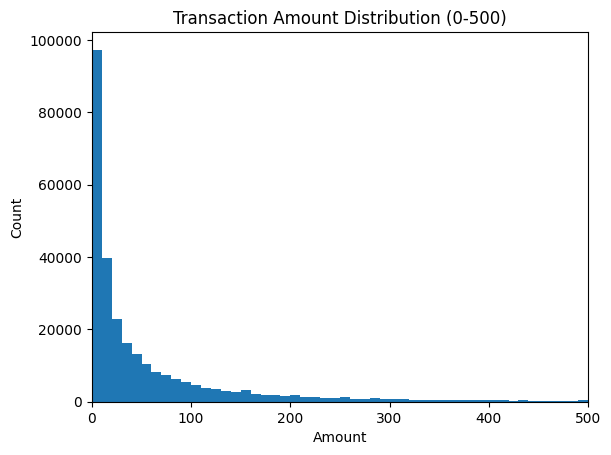

In [33]:
# 거래 금액 분포를 0~500 구간으로 확대하여 확인
plt.hist(df["Amount"], bins=50, range=(0, 500))
plt.xlim(0, 500)
plt.xlabel("Amount")
plt.ylabel("Count")
plt.title("Transaction Amount Distribution (0-500)")
plt.show()

In [34]:
# 정상 거래와 사기 거래의 주요 변수 통계 비교
comparison = df.groupby("Class")[["Amount", "V3", "V14"]].agg(["mean", "median"])

comparison

Amount               V3                 V14          
             mean median      mean    median      mean    median
Class                                                           
0       88.291022  22.00  0.012171  0.182158  0.012064  0.051947
1      122.211321   9.25 -7.033281 -5.075257 -6.971723 -6.729720

In [35]:
# 정상 거래(Class=0)에서만 중복 제거
normal_clean = df[df["Class"] == 0].drop_duplicates()

# 사기 거래(Class=1)는 중복도 모두 보존
fraud_keep = df[df["Class"] == 1]

# 다시 하나의 데이터프레임으로 합치기
df_clean = pd.concat([normal_clean, fraud_keep], ignore_index=True)

# 처리 전후 데이터 크기 확인
print("Before:", df.shape)
print("After:", df_clean.shape)

# 정상(0), 사기(1) 거래 개수 확인
print("\nClass counts:")
print(df_clean["Class"].value_counts())

Before: (284807, 31)
After: (283745, 31)

Class counts:
Class
0    283253
1       492
Name: count, dtype: int64


In [36]:
# 정제된 데이터에서 입력 데이터(X)와 정답 데이터(y) 분리
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

# 데이터 크기와 클래스 개수 확인
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass counts:")
print(y.value_counts())

X shape: (283745, 30)
y shape: (283745,)

Class counts:
Class
0    283253
1       492
Name: count, dtype: int64


In [37]:
# Train / Validation / Test 분할
from sklearn.model_selection import train_test_split

# 1차 분할: Train 70%, 나머지 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: 남은 30%를 Validation 15%, Test 15%로 나누기
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# 데이터 크기 확인
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# 클래스 개수 확인
print("\nTrain Class:")
print(y_train.value_counts())

print("\nValidation Class:")
print(y_val.value_counts())

print("\nTest Class:")
print(y_test.value_counts())

Train: (198621, 30) (198621,)
Validation: (42562, 30) (42562,)
Test: (42562, 30) (42562,)

Train Class:
Class
0    198277
1       344
Name: count, dtype: int64

Validation Class:
Class
0    42488
1       74
Name: count, dtype: int64

Test Class:
Class
0    42488
1       74
Name: count, dtype: int64


In [38]:
# 거래 금액(Amount) 스케일링
from sklearn.preprocessing import RobustScaler

# 원본 분할 데이터를 보호하기 위해 복사
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# RobustScaler 생성
amount_scaler = RobustScaler()

# Train 데이터로 기준 학습 + 변환
X_train["Amount"] = amount_scaler.fit_transform(
    X_train[["Amount"]]
).ravel()

# Validation / Test는 Train에서 학습한 기준으로 변환만
X_val["Amount"] = amount_scaler.transform(
    X_val[["Amount"]]
).ravel()

X_test["Amount"] = amount_scaler.transform(
    X_test[["Amount"]]
).ravel()

# 변환 결과 확인
print("Train Amount:")
print(X_train["Amount"].describe())

print("\nValidation Amount:")
print(X_val["Amount"].describe())

print("\nTest Amount:")
print(X_test["Amount"].describe())

Train Amount:
count    198621.000000
mean          0.919608
std           3.367956
min          -0.306582
25%          -0.227576
50%           0.000000
75%           0.772424
max         262.259372
Name: Amount, dtype: float64

Validation Amount:
count    42562.000000
mean         0.923918
std          3.474895
min         -0.306582
25%         -0.231880
50%         -0.011802
75%          0.751631
max        164.898778
Name: Amount, dtype: float64

Test Amount:
count    42562.000000
mean         0.930295
std          3.946521
min         -0.306582
25%         -0.226534
50%          0.000833
75%          0.776451
max        356.415996
Name: Amount, dtype: float64


In [39]:
# Time(초)을 0~23시의 시간(Hour)으로 변환
X_train["Hour"] = ((X_train["Time"] // 3600) % 24).astype(int)
X_val["Hour"] = ((X_val["Time"] // 3600) % 24).astype(int)
X_test["Hour"] = ((X_test["Time"] // 3600) % 24).astype(int)

# 기존 Time 열 제거
X_train = X_train.drop("Time", axis=1)
X_val = X_val.drop("Time", axis=1)
X_test = X_test.drop("Time", axis=1)

# 변환 결과 확인
print("Train Hour:")
print(X_train["Hour"].value_counts().sort_index())

print("\nHour range:")
print("Train:", X_train["Hour"].min(), "~", X_train["Hour"].max())
print("Validation:", X_val["Hour"].min(), "~", X_val["Hour"].max())
print("Test:", X_test["Hour"].min(), "~", X_test["Hour"].max())

Train Hour:
Hour
0      5313
1      2910
2      2331
3      2421
4      1541
5      2076
6      2862
7      5062
8      7170
9     11074
10    11639
11    11752
12    10760
13    10674
14    11550
15    11478
16    11449
17    11295
18    11832
19    11007
20    11754
21    12281
22    10813
23     7577
Name: count, dtype: int64

Hour range:
Train: 0 ~ 23
Validation: 0 ~ 23
Test: 0 ~ 23


In [40]:
# X와 y를 다시 합쳐 저장할 데이터프레임 만들기
train_processed = X_train.copy()
train_processed["Class"] = y_train.values

val_processed = X_val.copy()
val_processed["Class"] = y_val.values

test_processed = X_test.copy()
test_processed["Class"] = y_test.values

# data/processed/ 폴더에 CSV 파일로 저장
train_processed.to_csv("../data/processed/train_processed.csv", index=False)
val_processed.to_csv("../data/processed/validation_processed.csv", index=False)
test_processed.to_csv("../data/processed/test_processed.csv", index=False)

# 저장된 데이터 크기 확인
print("Train:", train_processed.shape)
print("Validation:", val_processed.shape)
print("Test:", test_processed.shape)

Train: (198621, 31)
Validation: (42562, 31)
Test: (42562, 31)
